In [1]:
!pip install pyspark

In [2]:

from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("111 BDA").getOrCreate()

print("Spark Ready!")

Spark Ready!


**Classification**


Accuracy: 0.7828054298642534
F1 Score: 0.7779894411543469
Precision: 0.7898062757142505
Recall: 0.7828054298642535
Cfn Matrix:
+--------+----------+-----+
|Survived|prediction|count|
+--------+----------+-----+
|       1|       0.0|   35|
|       0|       1.0|   13|
|       0|       0.0|  110|
|       1|       1.0|   63|
+--------+----------+-----+



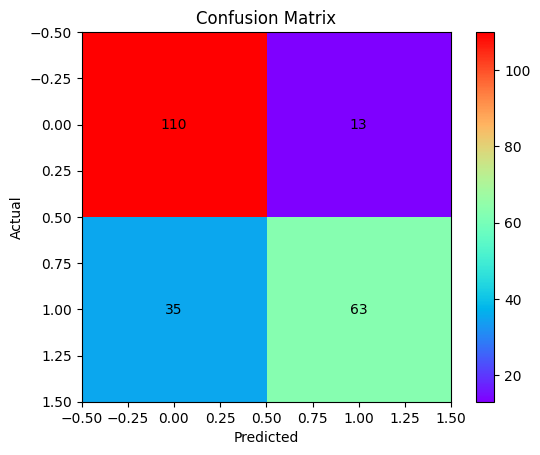

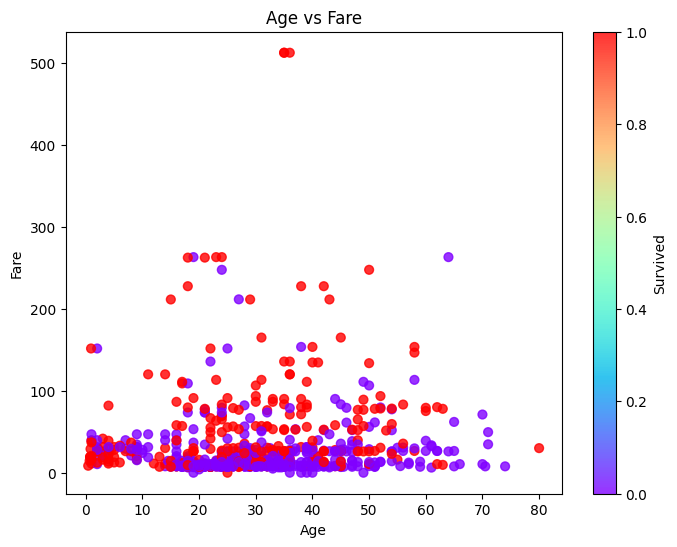

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

spark_df = spark.createDataFrame(df)

from pyspark.ml.feature import StringIndexer, VectorAssembler

spark_df = spark_df.select("Pclass","Sex","Age","Fare","Survived").dropna()

indexer = StringIndexer(inputCol="Sex", outputCol="SexIndex")
spark_df = indexer.fit(spark_df).transform(spark_df)

assembler = VectorAssembler(
    inputCols=["Pclass","SexIndex","Age","Fare"],
    outputCol="features"
)

data = assembler.transform(spark_df).select("features","Survived")

train, test = data.randomSplit([0.7,0.3])

from pyspark.ml.classification import LogisticRegression

model = LogisticRegression(labelCol="Survived").fit(train)
pred = model.transform(test)

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="Survived")

print("Accuracy:", evaluator.setMetricName("accuracy").evaluate(pred))
print("F1 Score:", evaluator.setMetricName("f1").evaluate(pred))
print("Precision:", evaluator.setMetricName("weightedPrecision").evaluate(pred))
print("Recall:", evaluator.setMetricName("weightedRecall").evaluate(pred))

print("Cfn Matrix:")
pred.groupBy("Survived","prediction").count().show()

pdf = pred.select("Survived","prediction").toPandas()
cm = pd.crosstab(pdf['Survived'], pdf['prediction'])

plt.imshow(cm, cmap='rainbow')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm.index)):
    for j in range(len(cm.columns)):
        plt.text(j, i, cm.iloc[i, j], ha='center', va='center', color='black')

plt.colorbar()
plt.show()
pdf2 = spark_df.toPandas()

plt.figure(figsize=(8,6))

plt.scatter(
    pdf2["Age"],
    pdf2["Fare"],
    c=pdf2["Survived"],
    cmap='rainbow',
    s=40,
    alpha=0.8
)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.colorbar(label="Survived")

plt.show()

**Clustering**

Silhouette Score: 0.7344130579787836
+----------+-----+
|prediction|count|
+----------+-----+
|         1|   39|
|         2|   50|
|         0|   61|
+----------+-----+



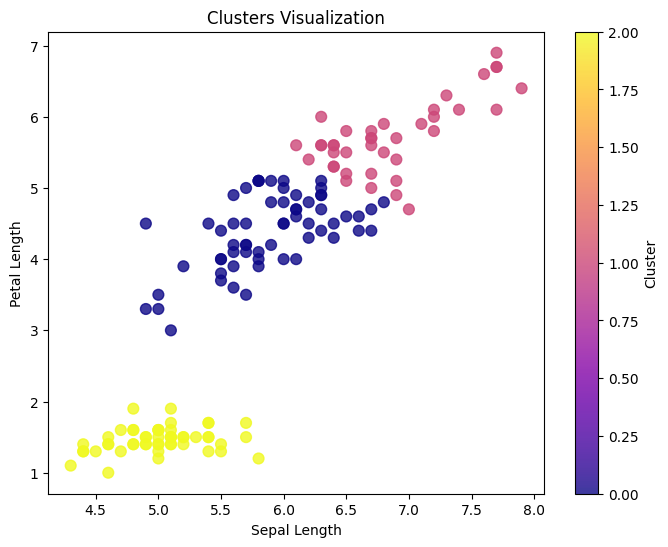

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
spark_df = spark.createDataFrame(df)
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(
    inputCols=["sepal_length","sepal_width","petal_length","petal_width"],
    outputCol="features"
)
data = assembler.transform(spark_df)
from pyspark.ml.clustering import KMeans
kmeans = KMeans(k=3)
model = kmeans.fit(data)
pred = model.transform(data)
from pyspark.ml.evaluation import ClusteringEvaluator
evaluator = ClusteringEvaluator()
print("Silhouette Score:", evaluator.evaluate(pred))
pred.groupBy("prediction").count().show()
pdf = pred.toPandas()
plt.figure(figsize=(8,6))

plt.scatter(
    pdf["sepal_length"],
    pdf["petal_length"],
    c=pdf["prediction"],
    cmap='plasma',
    s=60,
    alpha=0.8
)

plt.title("Clusters Visualization")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.colorbar(label="Cluster")

plt.show()

**Recommendation System**

In [7]:
import matplotlib.pyplot as plt
!wget https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -o ml-100k.zip
ratings = spark.read.csv("/content/ml-100k/u.data", sep="\t", inferSchema=True)
ratings = ratings.toDF("userId","movieId","rating","timestamp")
from pyspark.ml.recommendation import ALS
als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop"
)
model = als.fit(ratings)
pred = model.transform(ratings)
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)
print("RMSE:", evaluator.evaluate(pred))

user_recs = model.recommendForAllUsers(5)
user_recs.show(5, truncate=False)
pdf = ratings.toPandas()

--2026-04-19 18:31:19--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip’

ml-100k.zip         100%[===================>]   4.70M  14.1MB/s    in 0.3s    

2026-04-19 18:31:20 (14.1 MB/s) - ‘ml-100k.zip’ saved [4924029/4924029]

Archive:  ml-100k.zip
   creating: ml-100k/
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml-100k/u.data          
  inflating: ml-100k/u.genre         
  inflating: ml-100k/u.info          
  inflating: ml-100k/u.item          
  inflating: ml-100k/u.occupation    
  inflating: ml-100k/u.user          
  inflating: ml-100k/u1.base         
  inflating: ml-100k/u1.test         
  inflating: ml-100k/u2.ba

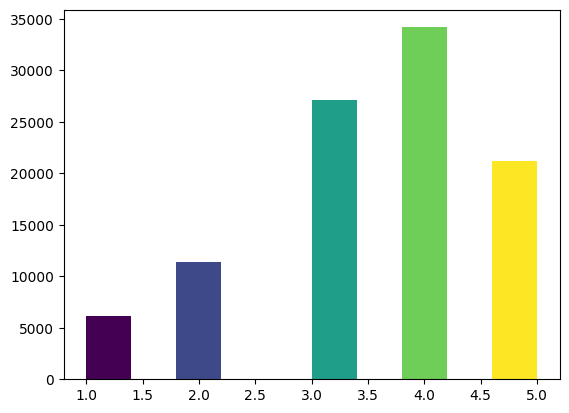

In [8]:

import numpy as np

counts, bins, patches = plt.hist(pdf["rating"])

colors = plt.cm.viridis(np.linspace(0, 1, len(patches)))

for patch, color in zip(patches, colors):
    patch.set_facecolor(color)
